# Phase 8 — Notebook 1: The Transfer Learning Revolution

> **Phase Continuity**: Phase 7 showed us the Transformer architecture and ended with the insight that pre-training on massive data unlocks general language understanding. This notebook explores exactly *how* and *why* that works — and why it changed everything in NLP.

---

## 1. The Old World: Training Every Model from Scratch

Before 2018, every NLP model was trained from the ground up for its specific task. A sentiment classifier was a completely separate model from a named entity recognizer, which was completely separate from a machine translation system.

This created two fundamental problems:

### 🚧 Problem 1: The Data Hunger Problem
Deep learning models require enormous amounts of *labeled* data to learn well. Labeled data means human annotators have manually tagged each example:
- 📧 Email: *spam* or *not spam* (classification label)
- 🎬 Review: *positive* or *negative* (sentiment label)
- 📰 Article: entity spans tagged as PERSON, ORG, LOCATION (NER labels)

Labeling is **slow, expensive, and requires domain expertise**. A typical NER dataset might take months to annotate properly.

### 🚧 Problem 2: Knowledge is Siloed
A sentiment model trained on movie reviews learned nothing that could help a translation model. Every model started from random weights — zero shared understanding. This is analogous to hiring a new employee for every single task, where each employee starts with no prior education whatsoever.

---

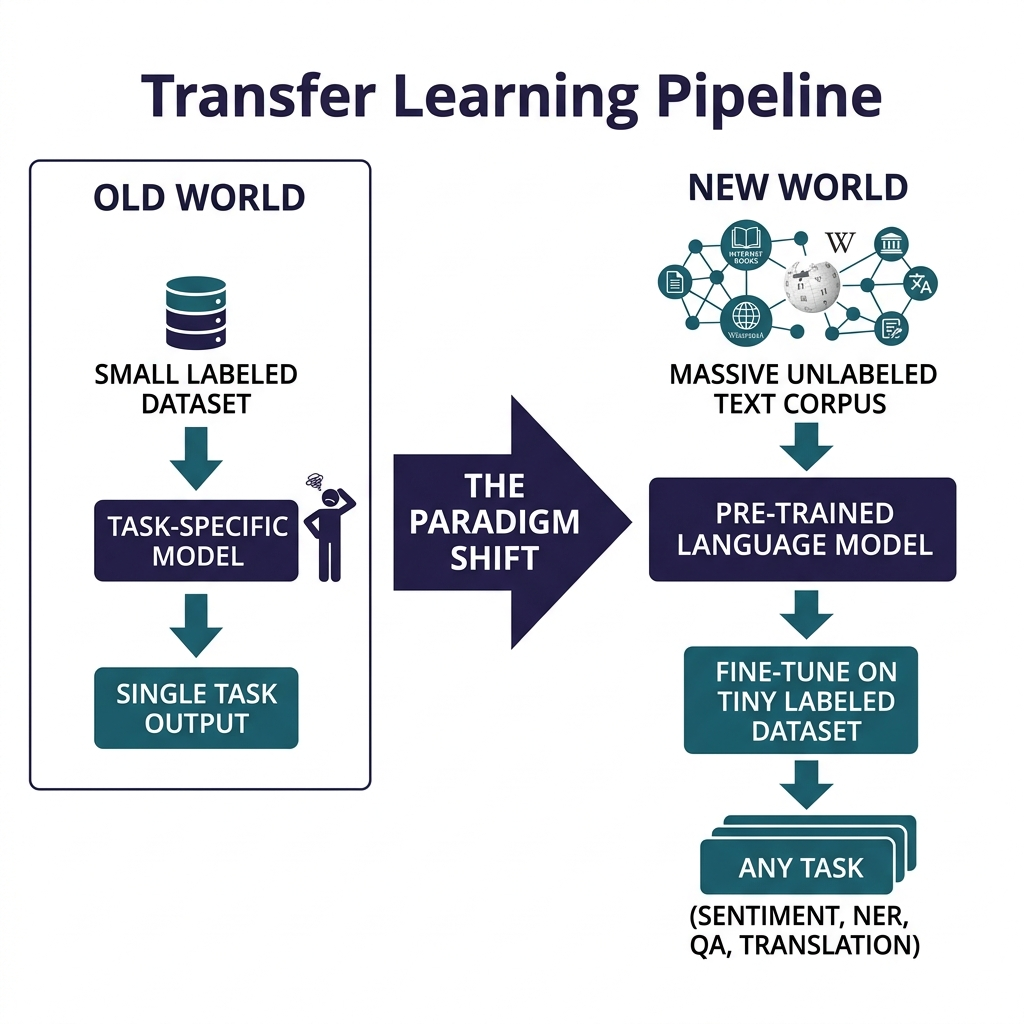

*Figure 1: The Transfer Learning Paradigm Shift — From task-specific scratch training to universal pre-training*



## 2. The New World: Pre-train, Then Fine-tune

The transfer learning revolution introduced a two-stage pipeline:

### Stage 1: Pre-training (Universal Language Understanding)
A large neural network is trained on **massive amounts of raw, unlabeled text** — billions of words scraped from books, Wikipedia, and the internet. The model's task is simple: *predict missing or next words*. It doesn't need human labels because the text itself provides the training signal.

During this process, the model silently learns:
- ✅ Grammar rules and syntactic structures
- ✅ World facts ("Paris is the capital of France")
- ✅ Semantic relationships between concepts
- ✅ Common sense reasoning patterns
- ✅ Stylistic and tonal nuances

### Stage 2: Fine-tuning (Task Specialization)
The pre-trained model's weights serve as a **starting point** — an initialized model that already understands language. We then train it on a *small, labeled dataset* specific to our target task (e.g., 10,000 sentiment labels). Because the model already understands language deeply, it needs very little data and training time to specialize.

### The University Analogy 🎓
> Think of pre-training as a 4-year university education in general knowledge — the student learns mathematics, science, writing, and critical thinking. Fine-tuning is then the 1-year medical residency. The student doesn't need to re-learn basic biology; they just need to apply their existing knowledge to a specific domain.

---

## 3. What Does a Pre-trained Model Actually Learn?

We can probe what BERT has learned by examining how it represents words in context. The following demonstration installs the Hugging Face `transformers` library and uses a pre-trained BERT model to extract embeddings — *without any fine-tuning*.

> 📦 **First-time setup**: This installs the `transformers` library (~10MB). Run once.

---

In [ ]:
# Install transformers if not already installed
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'transformers', 'torch', '--quiet'], check=True)
print('✅ Libraries ready.')

In [ ]:
import torch
from transformers import BertTokenizer, BertModel
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics.pairwise import cosine_similarity

# ── Load BERT (no fine-tuning — pure pre-trained knowledge) ──────────────────
print('Loading bert-base-uncased... (first run downloads ~440MB)')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.eval()
print('✅ BERT loaded.')

def get_word_embedding(sentence, target_word):
    """Extract BERT's contextual embedding for a specific word in a sentence."""
    inputs = tokenizer(sentence, return_tensors='pt')
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    with torch.no_grad():
        outputs = model(**inputs)
    hidden_states = outputs.last_hidden_state[0]  # (seq_len, 768)
    # Find the target word's token index
    for i, tok in enumerate(tokens):
        if target_word.lower() in tok.lower():
            return hidden_states[i].numpy()
    return None

# ── Contextual Embedding Demo: the word 'bank' ──────────────────────────────
sentences = [
    ("I deposited money at the bank yesterday.", 'bank'),
    ("She sat on the river bank watching the fish.", 'bank'),
    ("The bank approved the loan within two days.", 'bank'),
    ("We hiked along the steep bank of the river.", 'bank'),
]

embeddings = []
labels = []
for sent, word in sentences:
    emb = get_word_embedding(sent, word)
    if emb is not None:
        embeddings.append(emb)
        labels.append(sent[:35] + '...')

# Cosine similarity matrix
emb_matrix = np.array(embeddings)
sim_matrix = cosine_similarity(emb_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0.7, vmax=1.0)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels([f'S{i+1}' for i in range(len(labels))], fontsize=11)
ax.set_yticklabels([f'S{i+1}: {l}' for i,l in enumerate(labels)], fontsize=9)
ax.set_title("BERT Contextual Similarity of 'bank'\n(finance contexts vs. river contexts)", fontsize=13, fontweight='bold')
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{sim_matrix[i,j]:.3f}', ha='center', va='center', fontsize=10, fontweight='bold')
plt.colorbar(im, ax=ax, label='Cosine Similarity')
plt.tight_layout()
plt.savefig(r'outputs/p8_bank_contextual_similarity.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📊 Notice: Finance bank sentences (S1, S3) are MORE similar to each other.')
print('         River bank sentences (S2, S4) are MORE similar to each other.')
print('         BERT gives the SAME word DIFFERENT vectors based on CONTEXT!')

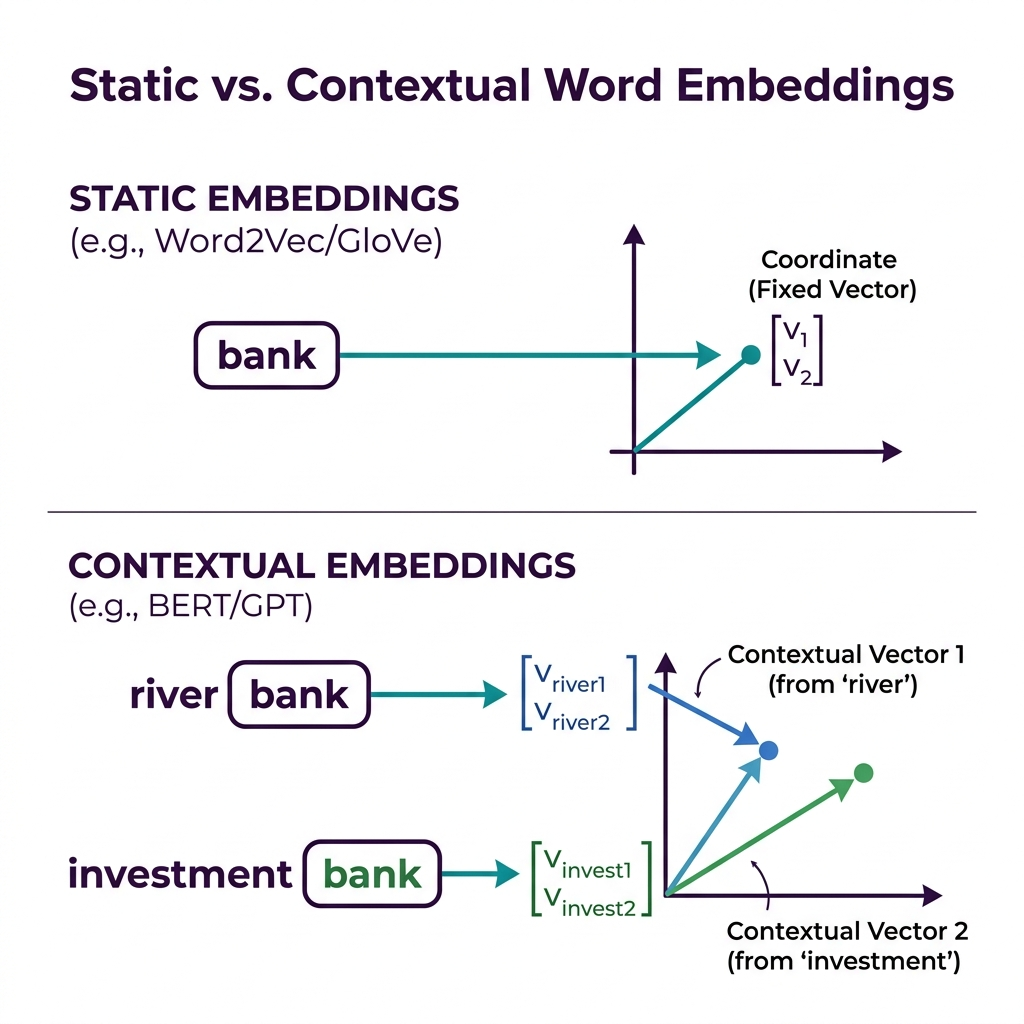

*Figure 2: Static Embeddings (Word2Vec) vs. Contextual Embeddings (BERT) — the same word gets different representations based on context*



## 4. Feature-based vs. Fine-tuning Approaches

When the NLP community first got access to pre-trained language models, there were two schools of thought on how to use them:

| Approach | How It Works | Example | Pros | Cons |
|---|---|---|---|---|
| **Feature-based** | Freeze pre-trained weights. Extract embeddings as fixed features for a downstream model. | ELMo (2018) | No GPU needed for fine-tuning. | Less task-specific adaptation. |
| **Fine-tuning (full)** | Start with pre-trained weights. Update ALL weights on labeled task data. | BERT, GPT (2018-2019) | Best performance on downstream tasks. | Requires more compute. |
| **Fine-tuning (gradual)** | Unfreeze layers gradually from top to bottom. | ULMFiT (2018) | Prevents catastrophic forgetting. | More complex training schedule. |
| **Prompt-based (modern)** | Don't update weights. Frame the task as a text completion in the prompt. | GPT-3 (2020) | Zero labeled data needed. | Requires massive models. |

The **full fine-tuning** approach of BERT became the standard and produced state-of-the-art results across 11 NLP benchmarks when published in 2018.

---

## 5. What Knowledge Layers Does Pre-training Build?

Research probing pre-trained models has revealed that knowledge is distributed across layers:

- **Lower layers** (1-4): Learn surface-level patterns — morphology, basic syntax, part-of-speech
- **Middle layers** (5-8): Learn syntax and grammar — sentence structure, dependencies, clauses
- **Upper layers** (9-12): Learn semantics — meaning, coreference, world knowledge, task-relevant features

This hierarchical learning mirrors how human language processing works — from phonemes to words to sentences to meaning.

---

In [ ]:
# Visualize the knowledge hierarchy in BERT
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Knowledge Hierarchy in Pre-trained BERT Layers', fontsize=14, fontweight='bold', pad=20)

layers = [
    (0.5, 0.5, 9, 2.0, '#E8F5E9', '#2E7D32', 'LAYERS 1-4: Surface Features',
     ['Part-of-speech (noun/verb/adj)', 'Capitalization patterns', 'Punctuation roles', 'Morphological features (plural, tense)']),
    (1.0, 2.8, 8, 2.0, '#E3F2FD', '#1565C0', 'LAYERS 5-8: Syntactic Structure',
     ['Subject-verb agreement', 'Phrase boundary detection', 'Syntactic dependency trees', 'Clause structure recognition']),
    (1.5, 5.1, 7, 2.0, '#EDE7F6', '#4527A0', 'LAYERS 9-12: Semantic Understanding',
     ['Word sense disambiguation (bank = finance/river)', 'Coreference resolution (he → John)', 'World knowledge & facts', 'Task-relevant semantic features']),
    (2.5, 7.5, 5, 2.0, '#FFF3E0', '#E65100', 'OUTPUT: Downstream Task Performance',
     ['Sentiment Classification', 'Named Entity Recognition', 'Question Answering', 'Text Classification']),
]

for x, y, w, h, bg, accent, title, bullets in layers:
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.1',
                                    facecolor=bg, edgecolor=accent, linewidth=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h - 0.3, title, ha='center', va='top',
            fontsize=10, fontweight='bold', color=accent)
    bullet_text = '  •  '.join(bullets)
    ax.text(x + w/2, y + h/2 - 0.2, bullet_text, ha='center', va='center',
            fontsize=7.5, color='#37474F', wrap=True,
            multialignment='center')
    if y > 0.4:
        ax.annotate('', xy=(5, y), xytext=(5, y - 0.5 + 0.05),
                    arrowprops=dict(arrowstyle='->', color='#90A4AE', lw=2))

plt.tight_layout()
plt.savefig(r'outputs/p8_knowledge_hierarchy.png', dpi=150, bbox_inches='tight')
plt.show()
print('BERT distributes knowledge hierarchically across its 12 transformer layers.')

## 6. Summary: Why Transfer Learning Transformed NLP

| Before (2017) | After Transfer Learning (2018+) |
|---|---|
| Train from random weights | Start from rich language understanding |
| Need millions of labeled examples | Need only thousands of labeled examples |
| Separate model per task | One pre-trained backbone, many fine-tuned heads |
| Task-specific architectures | Unified Transformer backbone |
| SOTA required huge datasets | SOTA achievable with small datasets |

### 🚀 What's Next
In Notebook 2, we'll look at a critical foundational step that makes this all possible: **how text is actually split into tokens** before being fed to these models. The tokenization algorithm turns out to be a fundamental design choice with major implications.

---
*Phase 8, Notebook 1 of 10 — NLP From Scratch: Foundation to Advanced*